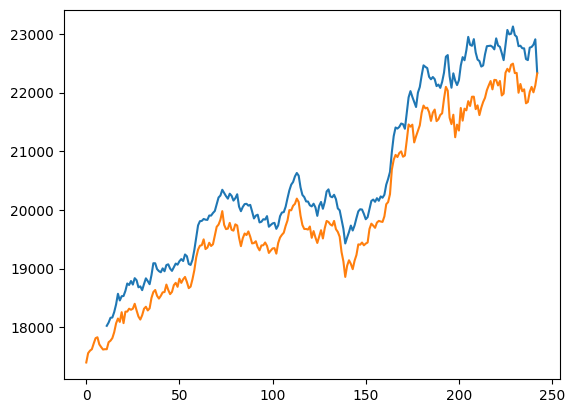

In [6]:
import yfinance as yf 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
def atr(data,period):
    values=np.zeros(len(data))
#     data['atr']=[]
#     for k in range(0,14):
#         data['atr'].iloc[k]=0
    for i in range(1,len(data)-period-1):
        tr=np.zeros(period)
        for j in range(0,period):
            np1=np.array([(data['High'].iloc[i+j]-data['Low'].iloc[i+j]),abs(data['High'].iloc[i+j]-data['Close'].iloc[i+j-1]),abs(data['Low'].iloc[i+j]-data['Close'].iloc[i+j-1])])
            tr[j]=np.sort(np1)[-1]
        values[i+period]=(tr.sum())/period
        
    return(values)

def supertrend(data,multiplier,atr_period):
    data['st']=((data['High']+data['Low'])/2)+  multiplier*(atr(data,atr_period))
    data['atr']=atr(data,atr_period)
    plt.plot(data['st'].iloc[atr_period+1:])
    plt.plot(data['Close'])
    plt.show()
    
df=pd.read_csv('ndata.csv')
supertrend(df,3,10)